<h1>Divisão do dataset: Treino, Teste e Validação - PBE + U</h1>

In [1]:
import numpy as np
from pathlib import Path

In [ ]:
structures: list[Path] = list(
    Path("/home/jvc/ZnO_database/data/PBEU_xsf_structures").iterdir()
)

print(f"Total Structures: {len(structures)}")
print("Examples:\t")


for i, struc in enumerate(structures[:10]):
    print(i, struc)


Total Structures: 4719
Examples:	
0 /home/jvc/ZnO_database/data/PBEU_xsf_structures/0827-PBEU-ZnO-3.24-1.70-222.xsf
1 /home/jvc/ZnO_database/data/PBEU_xsf_structures/4636-PBEU-ZnO-3.57-1.57-222-0.06.xsf
2 /home/jvc/ZnO_database/data/PBEU_xsf_structures/3249-PBEU-ZnO-2.92-1.66-321-0.06.xsf
3 /home/jvc/ZnO_database/data/PBEU_xsf_structures/2157-PBEU-ZnO-3.18-1.44-321-0.04.xsf
4 /home/jvc/ZnO_database/data/PBEU_xsf_structures/4170-PBEU-ZnO-3.37-1.47-312-0.06.xsf
5 /home/jvc/ZnO_database/data/PBEU_xsf_structures/1886-PBEU-ZnO-3.05-1.50-111-0.04.xsf
6 /home/jvc/ZnO_database/data/PBEU_xsf_structures/3511-PBEU-ZnO-3.05-1.63-111-0.06.xsf
7 /home/jvc/ZnO_database/data/PBEU_xsf_structures/0461-PBEU-ZnO-3.11-1.50-213.xsf
8 /home/jvc/ZnO_database/data/PBEU_xsf_structures/0154-PBEU-ZnO-2.98-1.44-313.xsf
9 /home/jvc/ZnO_database/data/PBEU_xsf_structures/1261-PBEU-ZnO-3.44-1.70-331.xsf


In [7]:
# Separa treino, teste e validação. (64%, 20%, 16%)
num_structures = len(structures)

training_percent = 0.64
test_percent = 0.20
validation_percent = 0.16

training_size = np.ceil(num_structures * training_percent).astype(int)
test_size = np.floor(num_structures * test_percent).astype(int)
validation_size = np.floor(num_structures * validation_percent).astype(int)


In [15]:
print(f"Tamanho da base: {num_structures}\n")
print(f"{'Conjunto':<15}{'Percentual':>12}{'Tamanho':>15}")
print("-" * 42)
print(f"{'Train':<15}{f'{training_percent:.1%}':>12}{training_size:>15}")
print(f"{'Validation':<15}{f'{validation_percent:.1%}':>12}{validation_size:>15}")
print(f"{'Test':<15}{f'{test_percent:.1%}':>12}{test_size:>15}")
print("-" * 42)

print()
print(f"{training_size + test_size = } (used by ænet train.x)")
print(f"{training_size + test_size + validation_size = }")

Tamanho da base: 4719

Conjunto         Percentual        Tamanho
------------------------------------------
Train                 64.0%           3021
Validation            16.0%            755
Test                  20.0%            943
------------------------------------------

training_size + test_size = 3964 (used by ænet train.x)
training_size + test_size + validation_size = 4719


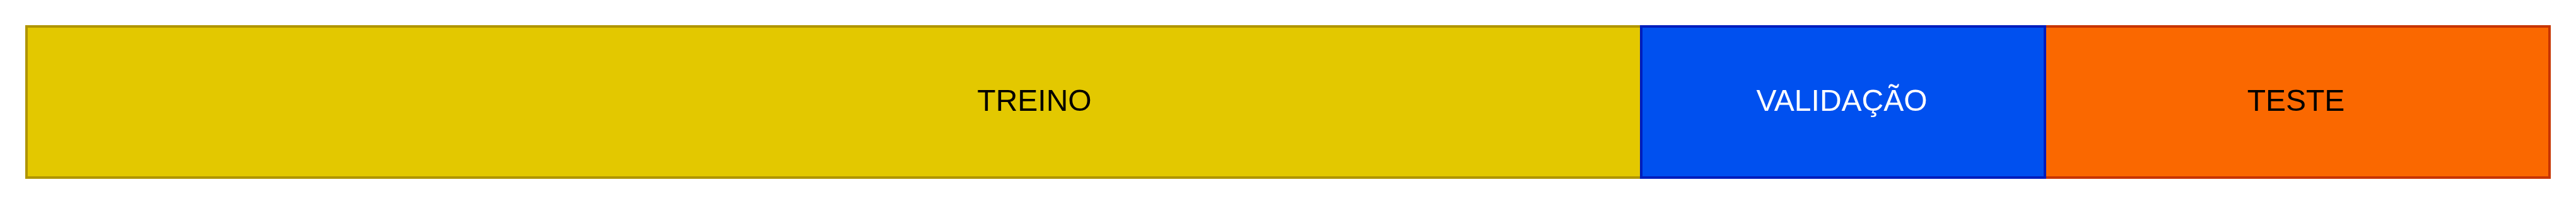

In [17]:
import shutil

# Training and Test Structures will be seen by aenet, so I choose
# a list of structures that will not be seen to validation (predict.x), and all the rest
# you be used for aenet's calculations.


# aenet_structures : treino + validação => 80%
# test_structures : test => 20%
test_structures: list[Path] = np.random.choice(
    structures, size=test_size, replace=False
)


# Escolher todas as estruturas, menos as de validação.
aenet_structures = set(structures) - set(test_structures)

# Create directories
outdirs = {
    "aenet_structures": Path("PBEU_training_set"),
    "test_structures": Path("PBEU_test_set"),
}

for outdir in outdirs.values():
    outdir.mkdir(exist_ok=True)

# Copy selected structures to respectively directory
for file in aenet_structures:
    shutil.copy(src=file, dst=outdirs["aenet_structures"])

for file in test_structures:
    shutil.copy(src=file, dst=outdirs["test_structures"])